In [2]:
import os
import pickle
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras as K


loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'
model_path = os.path.join(loadPath, 'models', 'cwgangp_generator_full_dataset.keras')
scaler_path = os.path.join(loadPath, 'models', 'cwgangp_full_dataset_scaler.pkl')
train_path = os.path.join(loadPath, 'train12720_raw_EEG.h5')

print(model_path)
print(scaler_path)
print(train_path)

generator = K.models.load_model(model_path, compile=False)

with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

print("generator loaded")
print("scaler loaded")





f_train = h5py.File(train_path, 'r')
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]
tr_subjects = f_train['subjects'][:]

print("tr_data shape:", tr_data.shape)
print("ytr shape:", ytr.shape)
print("unique raw labels:", np.unique(ytr))

ytr = ytr.astype(np.int32)
if np.array_equal(np.unique(ytr), np.array([1, 2, 3, 4])):
    ytr = ytr - 1

print("unique remapped labels:", np.unique(ytr))



def inverse_scale_trials(x_scaled, scaler):
    """
    x_scaled: (N, 640, 64, 1) or (N, 640, 64)
    return:   (N, 640, 64)
    """
    if x_scaled.ndim == 4:
        x_scaled = np.squeeze(x_scaled, axis=-1)

    n, t, c = x_scaled.shape
    x_flat = x_scaled.reshape(-1, c)
    x_inv = scaler.inverse_transform(x_flat)
    x_inv = x_inv.reshape(n, t, c)
    return x_inv

latent_dim = 128
samples_per_class = 8
num_classes = 4

all_labels = []
for cls in range(num_classes):
    all_labels.extend([cls] * samples_per_class)

sample_labels = tf.constant(np.array(all_labels).reshape(-1, 1), dtype=tf.int32)
sample_noise = tf.random.normal([len(all_labels), latent_dim], dtype=tf.float32)

sample_trials_scaled = generator([sample_noise, sample_labels], training=False).numpy()
sample_trials = inverse_scale_trials(sample_trials_scaled, scaler)

print("sample_trials_scaled shape:", sample_trials_scaled.shape)
print("sample_trials shape:", sample_trials.shape)
print("scaled min/max:", sample_trials_scaled.min(), sample_trials_scaled.max())
print("inverse-scaled min/max:", sample_trials.min(), sample_trials.max())






/home/sz4544/EEG-motor-imagery-main/project/models/cwgangp_generator_full_dataset.keras
/home/sz4544/EEG-motor-imagery-main/project/models/cwgangp_full_dataset_scaler.pkl
/home/sz4544/EEG-motor-imagery-main/project/train12720_raw_EEG.h5
generator loaded
scaler loaded
tr_data shape: (12720, 640, 64)
ytr shape: (12720,)
unique raw labels: [1. 2. 3. 4.]
unique remapped labels: [0 1 2 3]


I0000 00:00:1774016544.440507   10278 cuda_dnn.cc:461] Loaded cuDNN version 90800


sample_trials_scaled shape: (32, 640, 64, 1)
sample_trials shape: (32, 640, 64)
scaled min/max: -1.0 1.0
inverse-scaled min/max: -0.00015833728 9.32314e-05


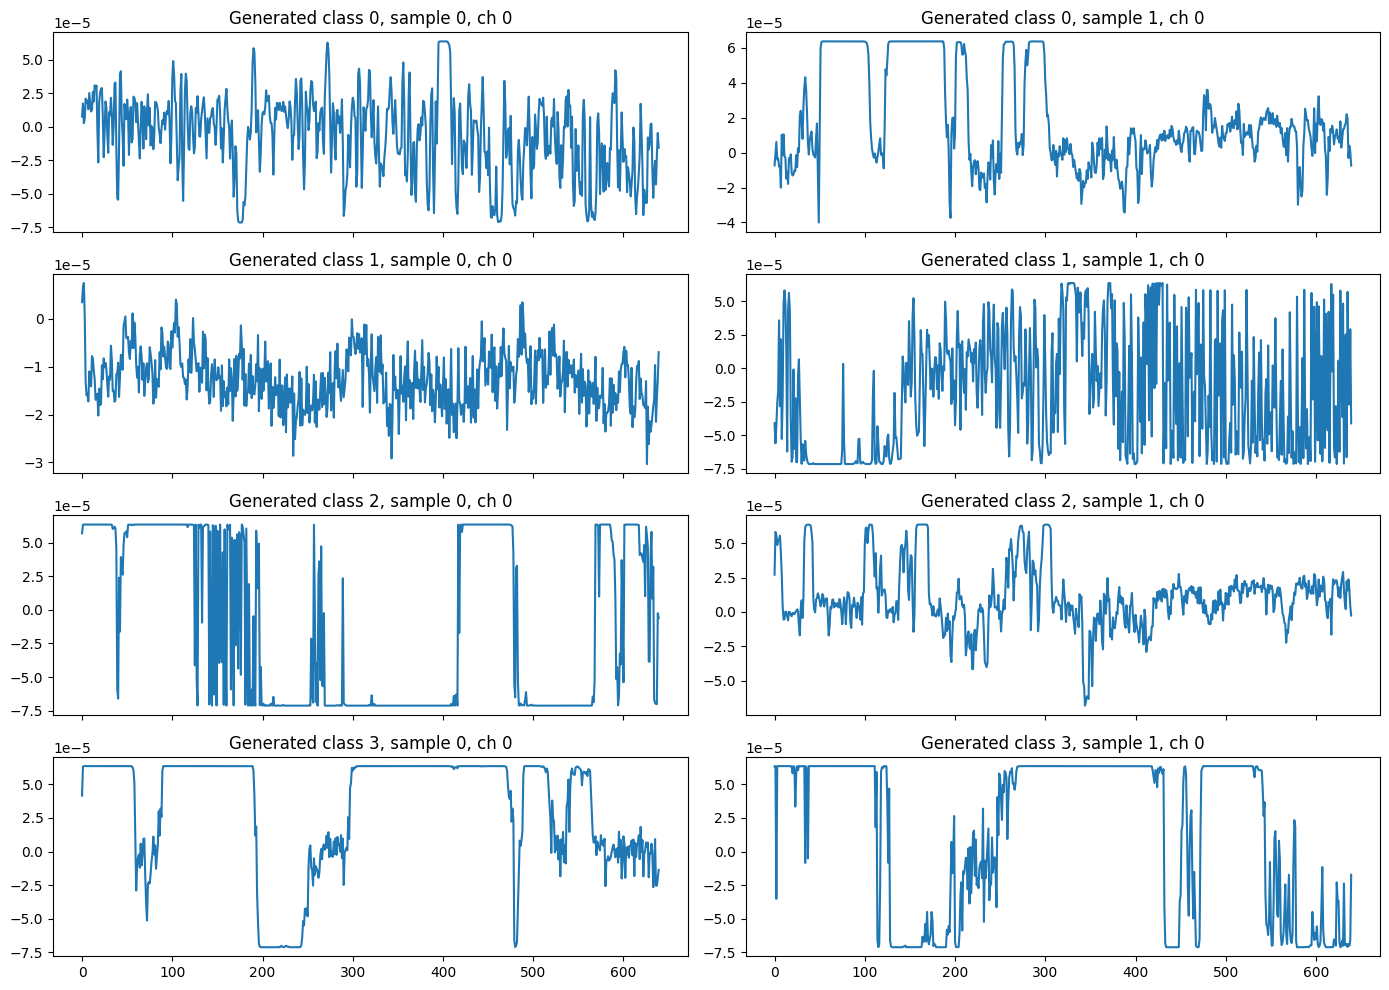

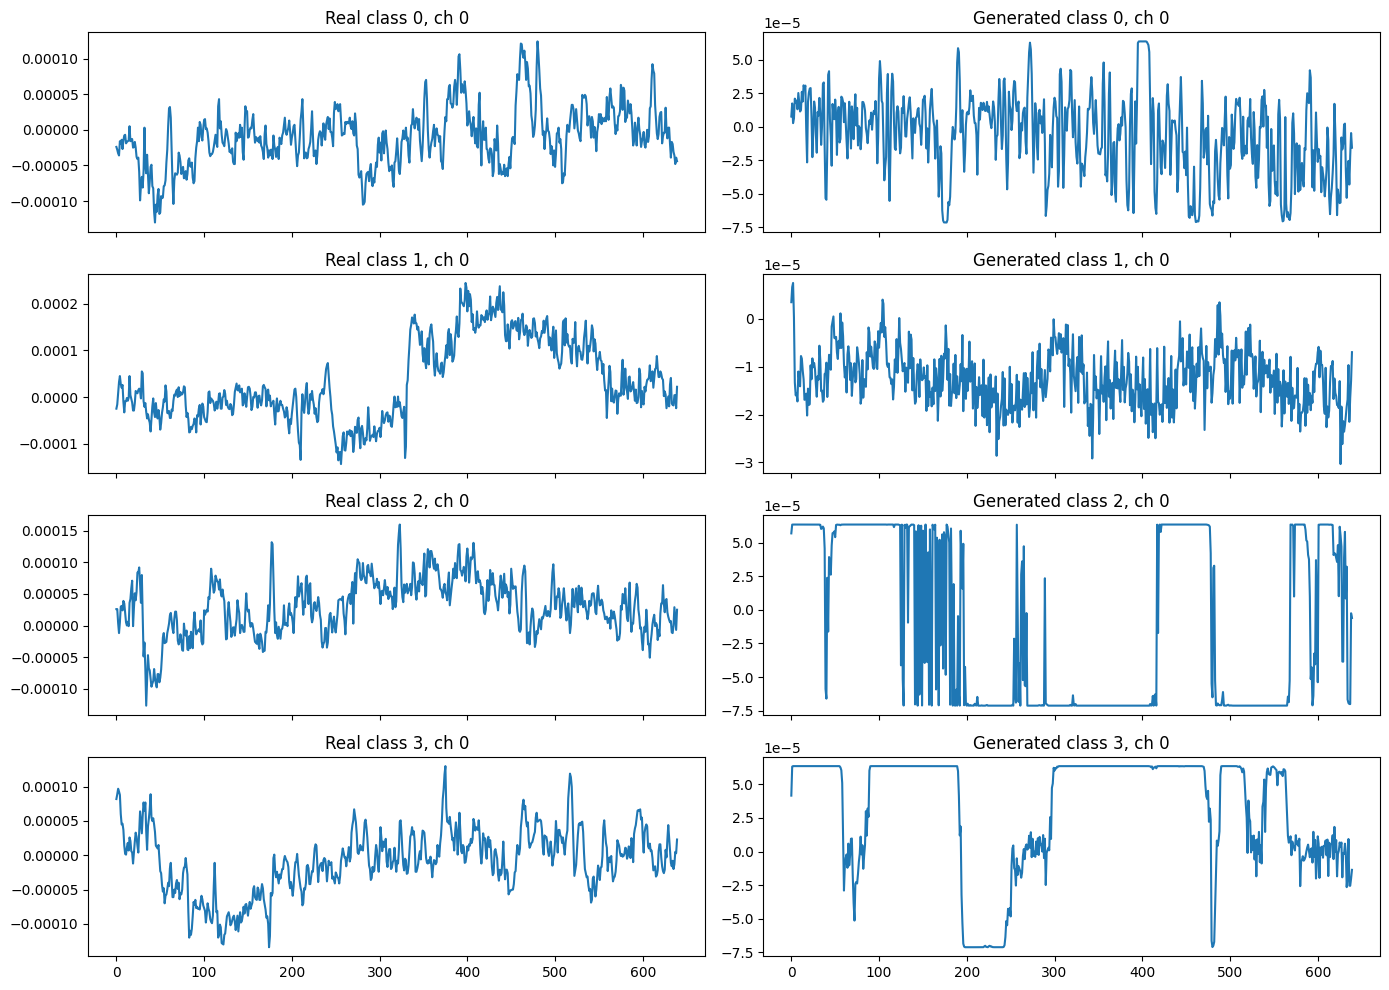

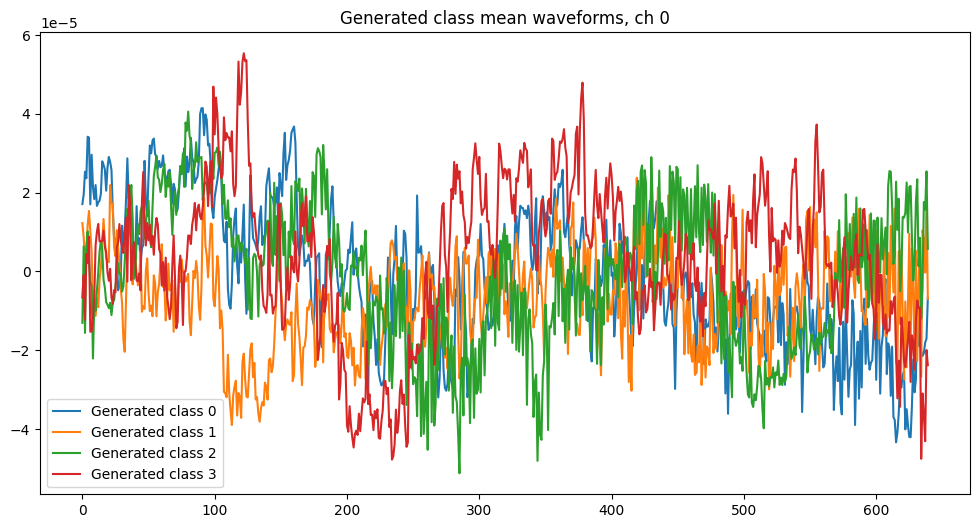

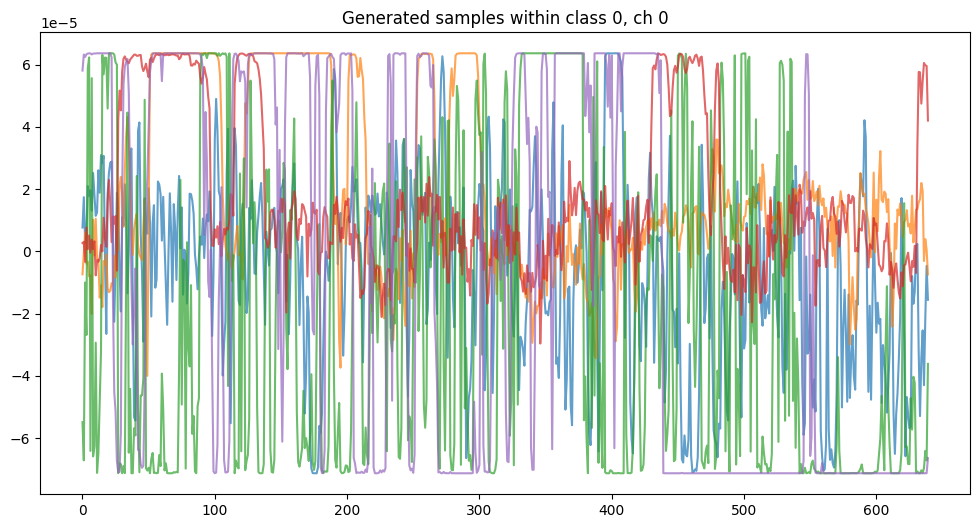

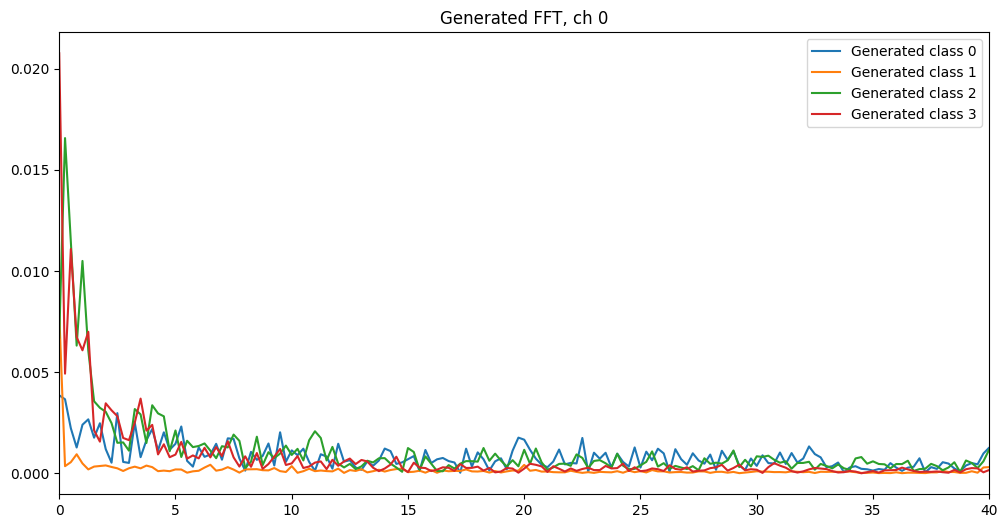

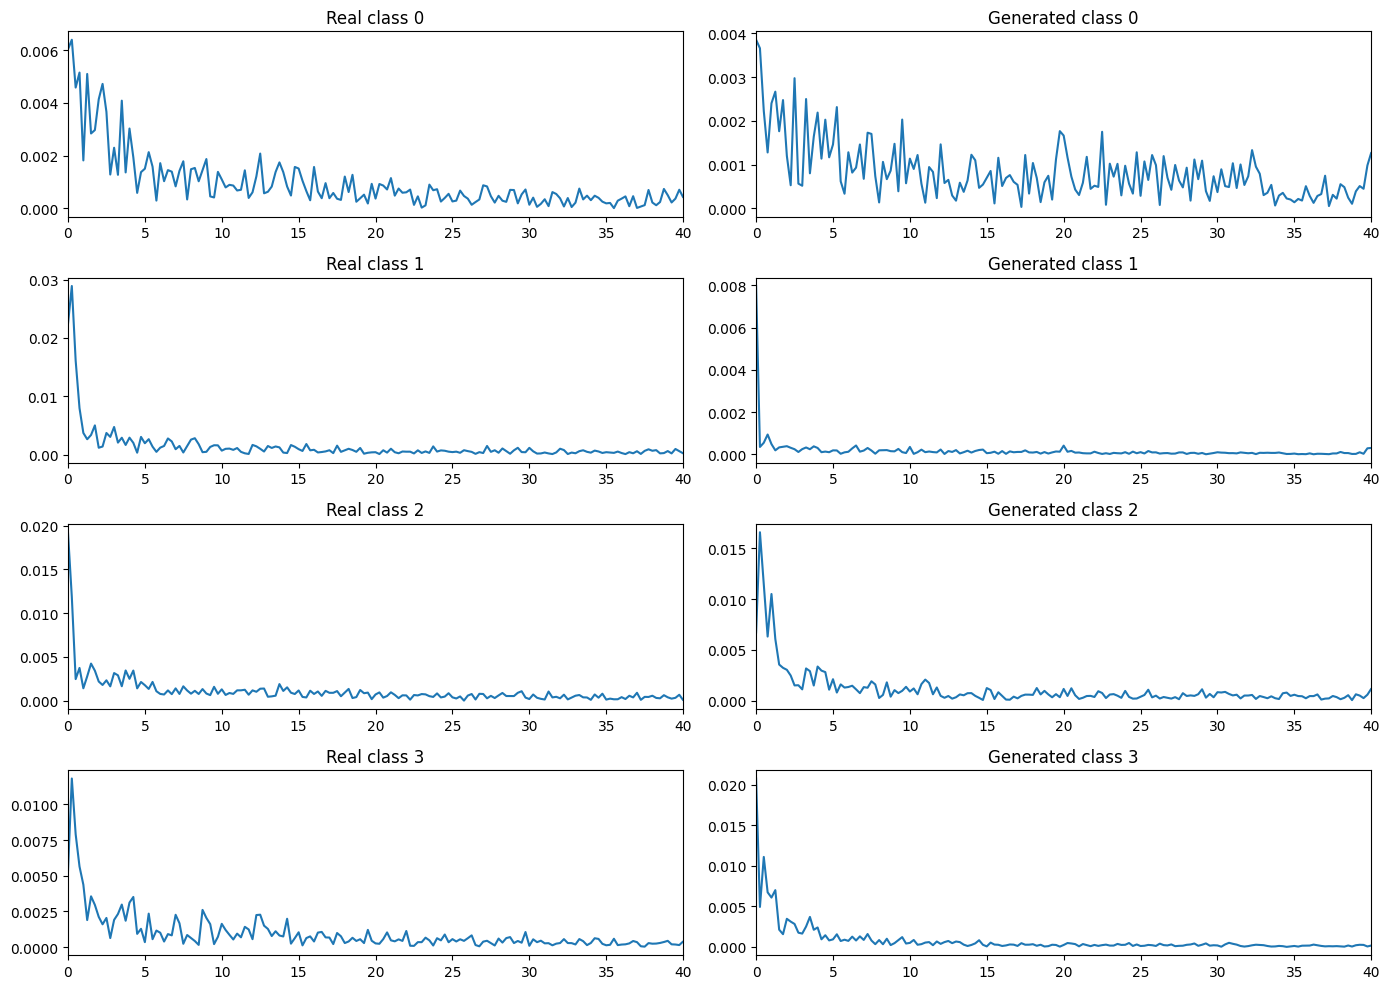

In [3]:
channel_idx = 0

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

for cls in range(4):
    for k in range(2):
        idx = cls * samples_per_class + k
        axes[cls, k].plot(sample_trials[idx, :, channel_idx])
        axes[cls, k].set_title(f"Generated class {cls}, sample {k}, ch {channel_idx}")

plt.tight_layout()
plt.show()

channel_idx = 0

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

for cls in range(4):
    real_idx = np.where(ytr == cls)[0][0]
    gen_idx = cls * samples_per_class

    axes[cls, 0].plot(tr_data[real_idx, :, channel_idx])
    axes[cls, 0].set_title(f"Real class {cls}, ch {channel_idx}")

    axes[cls, 1].plot(sample_trials[gen_idx, :, channel_idx])
    axes[cls, 1].set_title(f"Generated class {cls}, ch {channel_idx}")

plt.tight_layout()
plt.show()


channel_idx = 0

plt.figure(figsize=(12, 6))

for cls in range(4):
    cls_idx = np.where(np.array(all_labels) == cls)[0]
    cls_mean = sample_trials[cls_idx, :, channel_idx].mean(axis=0)
    plt.plot(cls_mean, label=f"Generated class {cls}")

plt.title(f"Generated class mean waveforms, ch {channel_idx}")
plt.legend()
plt.show()


channel_idx = 0
target_class = 0

plt.figure(figsize=(12, 6))

cls_idx = np.where(np.array(all_labels) == target_class)[0]
for idx in cls_idx[:5]:
    plt.plot(sample_trials[idx, :, channel_idx], alpha=0.7)

plt.title(f"Generated samples within class {target_class}, ch {channel_idx}")
plt.show()


def plot_fft(signal, fs=160, label=None):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    fft_vals = np.abs(np.fft.rfft(signal))
    plt.plot(freqs, fft_vals, label=label)

channel_idx = 0
fs = 160

plt.figure(figsize=(12, 6))

for cls in range(4):
    idx = cls * samples_per_class
    plot_fft(sample_trials[idx, :, channel_idx], fs=fs, label=f"Generated class {cls}")

plt.xlim(0, 40)
plt.title(f"Generated FFT, ch {channel_idx}")
plt.legend()
plt.show()


channel_idx = 0
fs = 160

fig, axes = plt.subplots(4, 2, figsize=(14, 10))

for cls in range(4):
    real_idx = np.where(ytr == cls)[0][0]
    gen_idx = cls * samples_per_class

    real_signal = tr_data[real_idx, :, channel_idx]
    gen_signal = sample_trials[gen_idx, :, channel_idx]

    freqs_real = np.fft.rfftfreq(len(real_signal), d=1/fs)
    fft_real = np.abs(np.fft.rfft(real_signal))

    freqs_gen = np.fft.rfftfreq(len(gen_signal), d=1/fs)
    fft_gen = np.abs(np.fft.rfft(gen_signal))

    axes[cls, 0].plot(freqs_real, fft_real)
    axes[cls, 0].set_xlim(0, 40)
    axes[cls, 0].set_title(f"Real class {cls}")

    axes[cls, 1].plot(freqs_gen, fft_gen)
    axes[cls, 1].set_xlim(0, 40)
    axes[cls, 1].set_title(f"Generated class {cls}")

plt.tight_layout()
plt.show()